### All Imports

In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('all_accelerometer_data_pids_13.csv')

In [3]:
df.head()

,time,pid,x,y,z
0,0,JB3156,0.0000,0.0000,0.0000
1,0,CC6740,0.0000,0.0000,0.0000
2,1493733882409,SA0297,0.0758,0.0273,-0.0102
3,1493733882455,SA0297,-0.0359,0.0794,0.0037
4,1493733882500,SA0297,-0.2427,-0.0861,-0.0163


In [4]:
print(df.shape)

(14057567, 5)


In [5]:
print(df.dtypes)
print(df['pid'].unique())  # pid 이름 확인 Name Verification

time      int64
pid         str
x       float64
y       float64
z       float64
dtype: object
<StringArray>
['JB3156', 'CC6740', 'SA0297', 'PC6771', 'BK7610', 'DC6359', 'MC7070',
 'MJ8002', 'BU4707', 'JR8022', 'HV0618', 'SF3079', 'DK3500']
Length: 13, dtype: str


In [6]:
# TAC 파일 하나 열어서 확인 Open a file and check it
tac_files = sorted(os.listdir('clean_tac/'))
print(tac_files)  # 파일명 목록 List of filenames

['BK7610_clean_TAC.csv', 'BU4707_clean_TAC.csv', 'CC6740_clean_TAC.csv', 'DC6359_clean_TAC.csv', 'DK3500_clean_TAC.csv', 'HV0618_clean_TAC.csv', 'JB3156_clean_TAC.csv', 'JR8022_clean_TAC.csv', 'MC7070_clean_TAC.csv', 'MJ8002_clean_TAC.csv', 'PC6771_clean_TAC.csv', 'SA0297_clean_TAC.csv', 'SF3079_clean_TAC.csv']


In [7]:
all_tac_list = []

for filename in tac_files:
    if not filename.endswith('.csv'):
        continue

    pid = filename.split('_')[0]
    temp_df = pd.read_csv(f'clean_tac/{filename}')
    temp_df['pid'] = pid

    # 음수 노이즈 제거 Negative Noise removal
    temp_df['TAC_Reading'] = temp_df['TAC_Reading'].clip(lower=0)

    # 레이블 생성 Create label
    temp_df['label'] = (temp_df['TAC_Reading'] >= 0.08).astype(int)

    # TAC_Reading > 0.08, label=1 (drunk), else label=0.

    # timestamp(초 seconds) → time(밀리초 milliseconds) 변환 conversion
    temp_df['time'] = temp_df['timestamp'] * 1000

    all_tac_list.append(temp_df)

df_tac = pd.concat(all_tac_list, ignore_index=True)

# 확인 check
print("df_tac 컬럼 column:", df_tac.columns.tolist())
print("df_tac 행 수 number of rows:", len(df_tac))
print(df_tac.head(30))

df_tac 컬럼 column: ['timestamp', 'TAC_Reading', 'pid', 'label', 'time']
df_tac 행 수 number of rows: 715
     timestamp  TAC_Reading     pid  label           time
0   1493718714     0.000000  BK7610      0  1493718714000
1   1493720697     0.001573  BK7610      0  1493720697000
2   1493721027     0.002144  BK7610      0  1493721027000
3   1493721357     0.000877  BK7610      0  1493721357000
4   1493721686     0.000000  BK7610      0  1493721686000
5   1493722016     0.000000  BK7610      0  1493722016000
6   1493722345     0.000000  BK7610      0  1493722345000
7   1493722674     0.001808  BK7610      0  1493722674000
8   1493723003     0.004542  BK7610      0  1493723003000
9   1493724832     0.005185  BK7610      0  1493724832000
10  1493725160     0.003094  BK7610      0  1493725160000
11  1493725474     0.000000  BK7610      0  1493725474000
12  1493725804     0.000000  BK7610      0  1493725804000
13  1493727636     0.000744  BK7610      0  1493727636000
14  1493729467     0.009188 

## HERE !! ?? thinking about adding 'between' state. w~0.08. we can add increase accuracy..?
---------------------------------------------------------------------------------------

In [8]:
for fname in tac_files:
    sample = pd.read_csv(f'clean_tac/{fname}')
    pid    = fname.split('_')[0]
    print(f"=== {pid} ===")
    print(f"  shape: {sample.shape}")
    print(f"  columns: {sample.columns.tolist()}")
    print(sample.head(3).to_string())
    print()

=== BK7610 ===
  shape: (57, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Reading
0  1493718714    -0.000482
1  1493720697     0.001573
2  1493721027     0.002144

=== BU4707 ===
  shape: (57, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Reading
0  1493718714    -0.000482
1  1493720697     0.001573
2  1493721027     0.002144

=== CC6740 ===
  shape: (56, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Reading
0  1493723434     0.003947
1  1493725257     0.000898
2  1493725585    -0.000894

=== DC6359 ===
  shape: (55, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Reading
0  1493719224    -0.002079
1  1493721045     0.000898
2  1493721360     0.002095

=== DK3500 ===
  shape: (51, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Reading
0  1493727820     0.000215
1  1493728019     0.001716
2  1493729841     0.001921

=== HV0618 ===
  shape: (54, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Read

'''가속도: 40Hz * 28시간 = 약 4,032,000 샘플 (1명당)
TAC:    30분 간격 * 28시간 = 57행 (1명당)

→ 가속도 1행당 TAC 1개를 붙여야 함
→ 30분 구간 안의 모든 가속도에 같은 TAC값이 붙음'''

Acceleration: 40 Hz * 28 hours = approx. 4,032,000 samples (per person)
TAC: 30-minute intervals * 28 hours = 57 rows (per person)

→ One TAC value must be assigned to each row of acceleration data.
→ All acceleration data points within a given 30-minute interval will be assigned the same TAC value.

In [9]:
# TAC 파일 원본 vs clean 비교
# TAC File Comparison: Original vs. Clean
pid_check = 'BK7610'
tac = pd.read_csv(f'clean_tac/{pid_check}_clean_TAC.csv')

print(f"=== {pid_check} TAC ===")
print(f"행 수 Number of Rows: {len(tac)}")
print(f"컬럼 Columns: {tac.columns.tolist()}")
print()
print(tac.to_string())
print("data loaded successfully.")

=== BK7610 TAC ===
행 수 Number of Rows: 57
컬럼 Columns: ['timestamp', 'TAC_Reading']

     timestamp  TAC_Reading
0   1493718714    -0.000482
1   1493720697     0.001573
2   1493721027     0.002144
3   1493721357     0.000877
4   1493721686    -0.001145
5   1493722016    -0.002159
6   1493722345    -0.001033
7   1493722674     0.001808
8   1493723003     0.004542
9   1493724832     0.005185
10  1493725160     0.003094
11  1493725474    -0.000291
12  1493725804    -0.002025
13  1493727636     0.000744
14  1493729467     0.009188
15  1493731296     0.022250
16  1493733371     0.037422
17  1493735217     0.052238
18  1493737046     0.065357
19  1493738847     0.076462
20  1493740845     0.085197
21  1493742871     0.090165
22  1493744843     0.089122
23  1493746883     0.080588
24  1493748731     0.065953
25  1493750580     0.050424
26  1493752430     0.041689
27  1493754265     0.046559
28  1493756113     0.067269
29  1493757960     0.099630
30  1493759807     0.134315
31  1493761652     0

# time matching check
## clean_tac 
## vs 
## all_accelerometer_data_pids_13

In [10]:
# 단위 직접 비교 — datetime 변환 없이
# Direct Unit Comparison — Without datetime Conversion
pid_check = 'BK7610'

accel_start = df[df['pid'] == pid_check]['time'].min()
accel_end   = df[df['pid'] == pid_check]['time'].max()
tac_start   = df_tac[df_tac['pid'] == pid_check]['time'].min()
tac_end     = df_tac[df_tac['pid'] == pid_check]['time'].max()

print(f"가속도 time 시작 Acceleration Time Start: {accel_start}")
print(f"가속도 time 끝 Acceleration Time End  : {accel_end}")
print(f"TAC    time 시작 TAC Time Start: {tac_start}")
print(f"TAC    time 끝 TAC Time End   : {tac_end}")
print()
print(f"자릿수 가속도 Number of digits in Acceleration: {len(str(accel_start))}")
print(f"자릿수 TAC Number of digits in TAC  : {len(str(tac_start))}")
print(f"단위 일치 Unit consistency   : {len(str(accel_start)) == len(str(tac_start))}")
print()
print(f"TAC가 가속도 시간 범위 안에 있나 Is the TAC within the acceleration time range?: {accel_start <= tac_start <= accel_end}")
print(f"겹치는 구간 (밀리초) Overlapping Interval (ms): {min(accel_end, tac_end) - max(accel_start, tac_start)}")

가속도 time 시작 Acceleration Time Start: 1493735870653
가속도 time 끝 Acceleration Time End  : 1493767770640
TAC    time 시작 TAC Time Start: 1493718714000
TAC    time 끝 TAC Time End   : 1493807899000

자릿수 가속도 Number of digits in Acceleration: 13
자릿수 TAC Number of digits in TAC  : 13
단위 일치 Unit consistency   : True

TAC가 가속도 시간 범위 안에 있나 Is the TAC within the acceleration time range?: False
겹치는 구간 (밀리초) Overlapping Interval (ms): 31899987


## BK7610 — Timestamp Alignment Verification

| | Start | End |
|---|---|---|
| Accelerometer | 1493735870653 ms | 1493767770640 ms |
| TAC | 1493718714000 ms | 1493807899000 ms |

**Digit count match:** Both 13 digits (milliseconds) 
**Overlapping window:** 31,899,987 ms ≈ 531 minutes ≈ 8.9 hours 

**Why TAC starts before accelerometer:**
TAC measurement began at ~09:51 UTC to establish a sober baseline,
while accelerometer recording started at ~14:37 UTC
when the bar crawl event began.
This is expected behavior — not a data error.

**Implication for merge_asof (backward):**
All accelerometer rows fall within the TAC recording window.
Without tolerance constraint, every accelerometer row
receives a valid TAC label from the most recent prior TAC reading.

# Run Under line!!

Try different directions: backward, forward, and nearest

In [11]:
combined_list = []

for pid in sorted(df['pid'].unique()):
    accel_pid = df[df['pid'] == pid].sort_values('time').reset_index(drop=True)
    tac_pid   = df_tac[df_tac['pid'] == pid].sort_values('time').reset_index(drop=True)

    merged_pid = pd.merge_asof(
        accel_pid,
        tac_pid[['time', 'label', 'TAC_Reading']],  # pid 컬럼 제거 Remove Column
        on='time',
        direction='nearest'
    )
    # pid 컬럼 직접 추가 Manually Add Column
    merged_pid['pid'] = pid

    combined_list.append(merged_pid)
    print(f"{pid}: {len(merged_pid):,}rows | "
          f"NaN {merged_pid['label'].isna().sum():,}count")

combined_df = pd.concat(combined_list, ignore_index=True)
combined_df = combined_df.dropna(subset=['label'])
combined_df['label'] = combined_df['label'].astype(int)

print(f"\nall: {len(combined_df):,}rows")
print(f"drunk rate: {combined_df['label'].mean()*100:.1f}%")

print("\n=== pid별 결과 Results ===")
for pid, group in combined_df.groupby('pid'):
    print(f"{pid}: {len(group):,} rows | drunk {group['label'].mean()*100:.2f}%")

BK7610: 1,225,727rows | NaN 0count
BU4707: 447,423rows | NaN 0count
CC6740: 2,374,695rows | NaN 0count
DC6359: 591,358rows | NaN 0count
DK3500: 1,339,622rows | NaN 0count
HV0618: 1,876,013rows | NaN 0count
JB3156: 1,177,749rows | NaN 0count
JR8022: 307,526rows | NaN 0count
MC7070: 318,600rows | NaN 0count
MJ8002: 631,303rows | NaN 0count
PC6771: 2,141,701rows | NaN 0count
SA0297: 962,901rows | NaN 0count
SF3079: 662,949rows | NaN 0count

all: 14,057,567rows
drunk rate: 24.2%

=== pid별 결과 Results ===
BK7610: 1,225,727 rows | drunk 59.03%
BU4707: 447,423 rows | drunk 34.77%
CC6740: 2,374,695 rows | drunk 18.29%
DC6359: 591,358 rows | drunk 11.74%
DK3500: 1,339,622 rows | drunk 0.00%
HV0618: 1,876,013 rows | drunk 4.63%
JB3156: 1,177,749 rows | drunk 18.92%
JR8022: 307,526 rows | drunk 99.49%
MC7070: 318,600 rows | drunk 93.10%
MJ8002: 631,303 rows | drunk 42.16%
PC6771: 2,141,701 rows | drunk 3.05%
SA0297: 962,901 rows | drunk 11.42%
SF3079: 662,949 rows | drunk 99.93%


# Is person id(pid) : SF3079 merging error? 
### SF3079 : 662,949 row | drunk 99.9%

## EDA — TAC 파일 구조 확인
아래 셀은 데이터 검증 목적으로 작성된 탐색 코드입니다.
최종 파이프라인 실행 시 건너뛰어도 됩니다.

## EDA — TAC file structure test
Under this line until starting 'pipeline' Markshell is written for searching and finding good model trianing & sampling.
when you doing final Running, you can skip this

In [12]:
# SF3079 TAC all rows
sf_tac = df_tac[df_tac['pid'] == 'SF3079'].sort_values('time').reset_index(drop=True)
print(f"SF3079 TAC 행 수 Number of rows: {len(sf_tac)}")
print(sf_tac[['timestamp', 'time', 'TAC_Reading', 'label']].to_string())

SF3079 TAC 행 수 Number of rows: 54
     timestamp           time  TAC_Reading  label
0   1493722490  1493722490000     0.000000      0
1   1493724435  1493724435000     0.000000      0
2   1493724750  1493724750000     0.000000      0
3   1493725064  1493725064000     0.000510      0
4   1493725378  1493725378000     0.015509      0
5   1493725711  1493725711000     0.021869      0
6   1493726043  1493726043000     0.014518      0
7   1493727874  1493727874000     0.000030      0
8   1493728206  1493728206000     0.000000      0
9   1493730037  1493730037000     0.012789      0
10  1493731882  1493731882000     0.059805      0
11  1493733728  1493733728000     0.123564      1
12  1493735575  1493735575000     0.181307      1
13  1493737421  1493737421000     0.211410      1
14  1493739266  1493739266000     0.205234      1
15  1493741116  1493741116000     0.171436      1
16  1493742961  1493742961000     0.130305      1
17  1493744810  1493744810000     0.101965      1
18  1493746658  

In [13]:
print(sf_tac['label'].mean())

0.48148148148148145


In [14]:
# SF3079 가속도 시간 범위
# SF3079 time range for accelerometer
sf_accel = df[df['pid'] == 'SF3079']
print(f"\nAcc Start: {sf_accel['time'].min()}")
print(f"Acc End  : {sf_accel['time'].max()}")
print(f"TAC  Start  : {sf_tac['time'].min()}")
print(f"TAC  End    : {sf_tac['time'].max()}")


Acc Start: 1493739196712
Acc End  : 1493790825495
TAC  Start  : 1493722490000
TAC  End    : 1493805310000


In [15]:
# SF3079 merge 결과 확인 — TAC값이 실제로 어떻게 붙었는지
# Verifying the Merge Results — How the TAC values ​​were actually appended
sf_merged = combined_df[combined_df['pid'] == 'SF3079']
print(f"\nTAC_Reading 분포 distribution:")
print(sf_merged['TAC_Reading'].describe())
print(f"\nlabel=1 (drunk) 비율 ratio: {sf_merged['label'].mean()*100:.1f}%")

# TAC값 구간별 행 수
# TAC Row Count by Value Range
bins = [0, 0.02, 0.04, 0.08, 0.15, 0.30, 1.0]
print(sf_merged.groupby(pd.cut(sf_merged['TAC_Reading'], bins))['label'].count())


TAC_Reading 분포 distribution:
count    662949.000000
mean          0.127697
std           0.033600
min           0.039047
25%           0.101965
50%           0.130305
75%           0.159026
max           0.205234
Name: TAC_Reading, dtype: float64

label=1 (drunk) 비율 ratio: 99.9%
TAC_Reading
(0.02, 0.04]       494
(0.08, 0.15]    473986
(0.15, 0.3]     188469
Name: label, dtype: int64


## SF3079 — Data Validity Analysis

### Why does SF3079 show 99.9% drunk label?

**Accelerometer recording window:**
- Start: 1493739196712 ms → 15:33 UTC
- End:   1493790825495 ms → 05:53 UTC (~14 hours)

**TAC readings around accelerometer start:**

| TAC row | timestamp (ms)  | TAC value | label |
|---------|-----------------|-----------|-------|
| row 11  | 1493733728000   | 0.123     | 1     |
| row 12  | 1493735575000   | 0.181     | 1     |
| row 13  | 1493737421000   | 0.211     | 1     |

The accelerometer recording started **after the participant had already
been drinking** — TAC was already at 0.12~0.18 when data collection began.

**Two intoxication episodes were observed:**
- Episode 1: rows 11~23 (14:28 ~ 15:53 UTC)
- Episode 2: rows 31~43 (17:46 ~ 22:03 UTC)

### Why is TAC-based drunk% different from accelerometer-based drunk%?

| Metric              | Value  | Reason                                      |
|---------------------|--------|---------------------------------------------|
| TAC raw drunk%      | 48.1%  | 57 rows at 30-min intervals                 |
| Accelerometer drunk%| 99.9%  | 40Hz continuous — more rows in drunk period |

**Conclusion:** SF3079 is **not a data error**.
The high drunk% reflects the actual recording condition —
the participant was intoxicated for most of the accelerometer session.
This participant contains almost no sober accelerometer samples,
making it unsuitable for balanced evaluation.
Therefore, SF3079 is excluded from the test set and used
only as supplementary training data.

# pipeline Starting

In [16]:
for pid, group in df.groupby('pid'):
    print(f"{pid}: {len(group)} rows")

BK7610: 1225727 rows
BU4707: 447423 rows
CC6740: 2374695 rows
DC6359: 591358 rows
DK3500: 1339622 rows
HV0618: 1876013 rows
JB3156: 1177749 rows
JR8022: 307526 rows
MC7070: 318600 rows
MJ8002: 631303 rows
PC6771: 2141701 rows
SA0297: 962901 rows
SF3079: 662949 rows


In [17]:
print(df_tac['pid'].unique())

<StringArray>
['BK7610', 'BU4707', 'CC6740', 'DC6359', 'DK3500', 'HV0618', 'JB3156',
 'JR8022', 'MC7070', 'MJ8002', 'PC6771', 'SA0297', 'SF3079']
Length: 13, dtype: str


In [18]:
print(df_tac.shape)

(715, 5)


In [19]:
combined_df.head()

,time,pid,x,y,z,label,TAC_Reading
0,1493735870653,BK7610,0.1261,-0.0078,-0.0243,0,0.052238
1,1493735870679,BK7610,0.1336,-0.0697,-0.0446,0,0.052238
2,1493735870703,BK7610,0.1443,-0.0474,-0.0447,0,0.052238
3,1493735870729,BK7610,0.1255,-0.0038,0.0111,0,0.052238
4,1493735870753,BK7610,0.1076,0.0032,0.0276,0,0.052238


In [20]:
# Create magnitude column
combined_df['mag'] = (combined_df['x']**2 + combined_df['y']**2 + combined_df['z']**2)**0.5



In [21]:
def extract_window_features(group, window_size=400):
    # 'group' is the data for a single PID
    # window_size=100 assumes roughly 2 seconds if sampling is 50Hz
    
    current_pid = group.name 
    
    features = []
    
    # Ensure there is enough data for at least one window
    if len(group) < window_size:
        return pd.DataFrame()

    for i in range(0, len(group) - window_size, window_size // 2): 
        window = group.iloc[i:i+window_size]
        
        feat = {
            'pid': current_pid,  
            'label': window['label'].iloc[0], 
            'mag_mean': window['mag'].mean(),
            'mag_std': window['mag'].std(),
            'mag_max': window['mag'].max(),
            'mag_var': window['mag'].var(),
            'x_std': window['x'].std(),
            'y_std': window['y'].std(),
            'z_std': window['z'].std(),
            # Jerk: std of first-order finite difference of acceleration magnitude
            # Captures movement irregularity — higher under intoxication
            # Jerk: 가속도 크기의 1차 차분의 표준편차
            # Standard deviation of the first-order difference of acceleration magnitude
            # 움직임의 불규칙성을 측정 — 음주 시 높아짐
            # Measurement of Movement Irregularity — Increases with Alcohol Consumption
            'jerk_std': np.std(np.diff(window['mag'].values)),

            # Sway index: ratio of lateral (x-z plane) to vertical (y-axis) acceleration
            # Quantifies body sway relative to gravitational axis
            # Sway index: 수평(x-z 평면) 가속도 / 수직(y축) 가속도 비율
            # Ratio of Horizontal (x-z plane) Acceleration to Vertical (y-axis) Acceleration
            # 중력 방향 대비 신체 흔들림 정도를 정규화한 지표
            # An indicator normalizing the degree of body sway relative to the direction of gravity.
            'sway'    : (np.sqrt(window['x']**2 + window['z']**2)).mean() /
                        (np.abs(window['y']).mean() + 1e-6),
        }
        features.append(feat)
        
    return pd.DataFrame(features)

# Apply to each participant separately to avoid mixing data

windowed_data = (
    combined_df
    .groupby('pid')
    .apply(extract_window_features, include_groups=False)
    .reset_index(drop=True)
)




print(f"Created {len(windowed_data)} windows across {windowed_data['pid'].nunique()} participants.")
print(windowed_data.head())

Created 70268 windows across 13 participants.
      pid  label  mag_mean   mag_std   mag_max   mag_var     x_std     y_std  \
0  BK7610      0  0.061583  0.048708  0.302581  0.002372  0.037232  0.035707   
1  BK7610      0  0.048068  0.028718  0.148330  0.000825  0.019795  0.033638   
2  BK7610      0  0.059227  0.046154  0.296375  0.002130  0.024881  0.042238   
3  BK7610      0  0.046598  0.047955  0.296375  0.002300  0.023983  0.033073   
4  BK7610      0  0.030812  0.022895  0.144609  0.000524  0.017992  0.017101   

      z_std  jerk_std      sway  
0  0.057269  0.027480  2.069979  
1  0.039346  0.022587  1.438393  
2  0.056432  0.035197  1.470735  
3  0.052201  0.031731  1.890625  
4  0.027836  0.016769  2.170532  


In [22]:
X = windowed_data.drop(['label', 'pid'], axis=1)
y = windowed_data['label']
groups = windowed_data['pid']



In [23]:
# This ensures StandardScaler is fit ONLY on the training groups in each fold.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

gkf = GroupKFold(n_splits=5)

# 'cross_validate' allows us to see multiple metrics (Accuracy, F1, etc.)
metrics = ['accuracy', 'precision', 'recall', 'f1']
results = cross_validate(pipeline, X, y, groups=groups, cv=gkf, scoring=metrics)

print(f"Mean Accuracy: {np.mean(results['test_accuracy']):.3f}")
print(f"Mean F1-Score: {np.mean(results['test_f1']):.3f}")
print(f"Mean Recall (Sensitivity): {np.mean(results['test_recall']):.3f}")

Mean Accuracy: 0.688
Mean F1-Score: 0.285
Mean Recall (Sensitivity): 0.376


## I need more time to change underline. I worked for increasing F1 score, making better model. 
### I am tring to make trianing set which cares rate of Drunk during the measuring 'accer' datas. I can find it is diffrent by pid. For example one thing is almost 0. and athor 99% we have to care about this, when split the data. 
## under line, the code is before calculating the rate of drunk. I will change as a result

In [24]:
# ─── 데이터 준비 Data Preparation ──────────────────────────────────────────────
feature_cols = [c for c in windowed_data.columns
                if c not in ['pid', 'label']]

X = windowed_data[feature_cols]
y = windowed_data['label']

# We need to change this
# ─── 배분 정의 Distributive Justice ────────────────────────────────────────────────
pid_seed  = 'JB3156'
pid_val   = 'CC6740'
pid_train = ['SA0297', 'DC6359', 'MJ8002', 'BK7610', 'DK3500']
pid_test  = ['PC6771', 'HV0618', 'SF3079', 'BU4707', 'JR8022']
train_order = [pid_seed, pid_val] + pid_train



# ─── 비교할 모델 정의 Define Models for Comparison ─────────────────────────────────────────
# ImbPipeline: SMOTE가 포함될 때 사용 (imblearn 제공)
# ImbPipeline: Used when SMOTE is included (provided by imblearn)
# SMOTE는 train 데이터에만 적용되도록 pipeline 안에 넣음
# SMOTE is placed inside the pipeline to ensure it is applied only to the training data.

models = {
    # 1. Weighted Logistic Regression
    'Logistic (weighted)': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',  # 음주 24% 불균형 자동 보정 24% Automatic Correction for Alcohol-Induced Imbalance
            max_iter=1000,
            random_state=42
        ))
    ]),

    # 2. Logistic Regression + SMOTE (오버샘플링 Oversampling)
    'Logistic + SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),  # 소수 클래스 합성 샘플 생성 Generation of Synthetic Samples for Minority Classes
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),

    # 3. Random Forest (class_weight)
    'Random Forest (weighted)': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42
        ))
    ]),

    # 4. Random Forest + SMOTE
    'Random Forest + SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    # 5. Gradient Boosting (불균형에 강함 Resilient to Imbalance)
    'Gradient Boosting': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),
}

# ─── Walk-forward validation ──────────────────────────────────
print("=" * 60)
print("Walk-forward validation")
print("=" * 60)

# 모델별 fold 결과 저장
# Save Fold Results by Model
all_results = {name: [] for name in models}

for i in range(1, len(train_order)):
    seen  = train_order[:i]
    next_ = train_order[i]

    train_df = windowed_data[windowed_data['pid'].isin(seen)]
    test_df  = windowed_data[windowed_data['pid'] == next_]

    X_train = train_df[feature_cols]
    y_train = train_df['label']
    X_test  = test_df[feature_cols]
    y_test  = test_df['label']

    print(f"\nFold {i}: train={[p[:4] for p in seen]} → test={next_}")
    print(f"  train: {len(X_train):,}개 samples | test: {len(X_test):,}개 samples | "
          f"음주 비율 Drunk rate train={y_train.mean()*100:.1f}% test={y_test.mean()*100:.1f}%")

    for name, pipe in models.items():
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        f1_drunk  = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_sober  = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
        f1_macro  = f1_score(y_test, y_pred, average='macro', zero_division=0)

        all_results[name].append({
            'fold'     : i,
            'test_pid' : next_,
            'f1_drunk' : round(f1_drunk, 3),
            'f1_sober' : round(f1_sober, 3),
            'f1_macro' : round(f1_macro, 3),
        })
        print(f"  [{name}] f1_drunk={f1_drunk:.3f} | "
              f"f1_sober={f1_sober:.3f} | f1_macro={f1_macro:.3f}")

# ─── Walk-forward 결과 요약 Summary of Results ───────────────────────────────────
print("\n" + "=" * 60)
print("Walk-forward 평균 성능 요약 Average Performance Summary")
print("=" * 60)

summary_rows = []
for name, folds in all_results.items():
    df_fold = pd.DataFrame(folds)
    summary_rows.append({
        'model'         : name,
        'f1_drunk (avg)': round(df_fold['f1_drunk'].mean(), 3),
        'f1_sober (avg)': round(df_fold['f1_sober'].mean(), 3),
        'f1_macro (avg)': round(df_fold['f1_macro'].mean(), 3),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('f1_drunk (avg)', ascending=False)
print(summary_df.to_string(index=False))

# ─── 최종 모델 선택 → 홀드아웃 테스트 Final Model Selection → Holdout Test ───────────────────────
# walk-forward에서 f1_drunk 가장 높은 모델 자동 선택
# Automatically select the model with the highest f1_drunk score in the walk-forward analysis.
best_model_name = summary_df.iloc[0]['model']
best_pipe = models[best_model_name]
print(f"\n최고 모델 Top Model: {best_model_name}")

# 7명 전체로 재학습 Retraining with all 7 members
train_final = windowed_data[windowed_data['pid'].isin(train_order)]
best_pipe.fit(train_final[feature_cols], train_final['label'])

# 홀드아웃 5명 테스트 Holdout Test with 5 Participants
print("\n" + "=" * 60)
print(f"홀드아웃 테스트 Holdout Test — {best_model_name}")
print("=" * 60)

holdout_rows = []
for pid in pid_test:
    test_df = windowed_data[windowed_data['pid'] == pid]
    y_true  = test_df['label']
    y_pred  = best_pipe.predict(test_df[feature_cols])

    f1_drunk = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    holdout_rows.append({
        'pid'      : pid,
        'n_windows': len(test_df),
        'drunk_pct': round(y_true.mean() * 100, 1),
        'f1_drunk' : round(f1_drunk, 3),
        'f1_macro' : round(f1_macro, 3),
    })

    print(f"\n{pid} (음주 Drunk {holdout_rows[-1]['drunk_pct']}%)")
    print(classification_report(y_true, y_pred,
                                 target_names=['sober', 'drunk'],
                                 zero_division=0))

print("\n홀드아웃 요약 Holdout Summary:")
print(pd.DataFrame(holdout_rows).to_string(index=False))

Walk-forward validation

Fold 1: train=['JB31'] → test=CC6740
  train: 5,887개 samples | test: 11,872개 samples | 음주 비율 Drunk rate train=18.9% test=18.3%
  [Logistic (weighted)] f1_drunk=0.674 | f1_sober=0.889 | f1_macro=0.782
  [Logistic + SMOTE] f1_drunk=0.674 | f1_sober=0.889 | f1_macro=0.781
  [Random Forest (weighted)] f1_drunk=0.646 | f1_sober=0.898 | f1_macro=0.772
  [Random Forest + SMOTE] f1_drunk=0.647 | f1_sober=0.896 | f1_macro=0.772
  [Gradient Boosting] f1_drunk=0.077 | f1_sober=0.900 | f1_macro=0.488

Fold 2: train=['JB31', 'CC67'] → test=SA0297
  train: 17,759개 samples | test: 4,813개 samples | 음주 비율 Drunk rate train=18.5% test=11.4%
  [Logistic (weighted)] f1_drunk=0.299 | f1_sober=0.567 | f1_macro=0.433
  [Logistic + SMOTE] f1_drunk=0.311 | f1_sober=0.600 | f1_macro=0.455
  [Random Forest (weighted)] f1_drunk=0.410 | f1_sober=0.870 | f1_macro=0.640
  [Random Forest + SMOTE] f1_drunk=0.427 | f1_sober=0.866 | f1_macro=0.646
  [Gradient Boosting] f1_drunk=0.406 | f1_sober=0

In [25]:
# tac_dict 다시 만들기 (앞에서 만든 게 있으면 이 부분 건너뛰어도 됨)
# Recreate `tac_dict` (If you have already created this previously, you may skip this section.)
tac_dir = 'clean_tac/'
tac_dict = {}
for fname in os.listdir(tac_dir):
    if fname.endswith('.csv'):
        pid = fname.replace('_clean_TAC.csv', '')
        df_tac = pd.read_csv(os.path.join(tac_dir, fname))
        tac_dict[pid] = df_tac

print("로드된 pid:", sorted(tac_dict.keys()))
# 13명 전체 TAC 원본 확인
# Verify Original TACs for All 13 Individuals
print("=" * 60)
print("전체 TAC 원본 통계 Overall TAC Raw Statistics")
print("=" * 60)

tac_summary = []
for pid in sorted(tac_dict.keys()):
    tac = tac_dict[pid]
    above_08 = (tac['TAC_Reading'] >= 0.08).mean() * 100
    tac_summary.append({
        'pid'        : pid,
        'n_rows'     : len(tac),
        'min'        : round(tac['TAC_Reading'].min(), 4),
        'max'        : round(tac['TAC_Reading'].max(), 4),
        'mean'       : round(tac['TAC_Reading'].mean(), 4),
        'pct_>=0.08' : round(above_08, 1),
    })

tac_df = pd.DataFrame(tac_summary).sort_values('pct_>=0.08', ascending=False)
print(tac_df.to_string(index=False))

로드된 pid: ['BK7610', 'BU4707', 'CC6740', 'DC6359', 'DK3500', 'HV0618', 'JB3156', 'JR8022', 'MC7070', 'MJ8002', 'PC6771', 'SA0297', 'SF3079']
전체 TAC 원본 통계 Overall TAC Raw Statistics
   pid  n_rows     min    max   mean  pct_>=0.08
SF3079      54 -0.0283 0.2114 0.0687        48.1
MC7070      56 -0.0124 0.1967 0.0630        41.1
JR8022      47 -0.0122 0.2133 0.0671        40.4
CC6740      56 -0.0030 0.2447 0.0660        30.4
MJ8002      59 -0.0029 0.2416 0.0506        27.1
DC6359      55 -0.0043 0.1534 0.0435        25.5
BK7610      57 -0.0027 0.1718 0.0413        22.8
BU4707      57 -0.0027 0.1718 0.0413        22.8
SA0297      58 -0.0213 0.1826 0.0431        19.0
HV0618      54 -0.0064 0.1936 0.0390        16.7
DK3500      51 -0.0034 0.1275 0.0244         9.8
JB3156      55 -0.0012 0.0964 0.0294         7.3
PC6771      56 -0.0094 0.0919 0.0239         7.1


In [26]:
# combined_df 기준으로도 한 번 더 확인 (merge 후 레이블이 제대로 붙었는지)
# Double-check against `combined_df` as well (to ensure labels were correctly assigned after the merge).
print("\n" + "=" * 60)
print("combined_df 기준 레이블 분포 (merge 후) Label Distribution Based on combined_df (After Merge)")
print("=" * 60)

merged_summary = []
for pid, group in combined_df.groupby('pid'):
    merged_summary.append({
        'pid'        : pid,
        'n_rows'     : len(group),
        'label_1_pct': round(group['label'].mean() * 100, 1),
        'tac_min'    : round(group['TAC_Reading'].min(), 4),
        'tac_max'    : round(group['TAC_Reading'].max(), 4),
        'tac_mean'   : round(group['TAC_Reading'].mean(), 4),
    })

merged_df_summary = pd.DataFrame(merged_summary).sort_values(
    'label_1_pct', ascending=False)
print(merged_df_summary.to_string(index=False))


combined_df 기준 레이블 분포 (merge 후) Label Distribution Based on combined_df (After Merge)
   pid  n_rows  label_1_pct  tac_min  tac_max  tac_mean
SF3079  662949         99.9   0.0390   0.2052    0.1277
JR8022  307526         99.5   0.0506   0.2068    0.1366
MC7070  318600         93.1   0.0000   0.1654    0.1270
BK7610 1225727         59.0   0.0417   0.1718    0.0960
MJ8002  631303         42.2   0.0000   0.2416    0.0862
BU4707  447423         34.8   0.0417   0.0996    0.0654
JB3156 1177749         18.9   0.0024   0.0964    0.0619
CC6740 2374695         18.3   0.0039   0.2447    0.0485
DC6359  591358         11.7   0.0057   0.1221    0.0595
SA0297  962901         11.4   0.0000   0.1826    0.0314
HV0618 1876013          4.6   0.0000   0.1936    0.0176
PC6771 2141701          3.1   0.0000   0.0900    0.0175
DK3500 1339622          0.0   0.0030   0.0712    0.0166


In [27]:
person_stats = windowed_data.groupby('pid').agg(
    n_windows   = ('label', 'count'),
    drunk_pct   = ('label', 'mean'),
    n_drunk     = ('label', 'sum'),
).reset_index()

person_stats['drunk_pct'] = (person_stats['drunk_pct'] * 100).round(1)
person_stats = person_stats.sort_values('drunk_pct', ascending=False)
print(person_stats.to_string(index=False))


   pid  n_windows  drunk_pct  n_drunk
SF3079       3313      100.0     3313
JR8022       1536       99.6     1530
MC7070       1591       93.1     1481
BK7610       6127       59.0     3615
MJ8002       3155       42.2     1332
BU4707       2236       34.7      776
JB3156       5887       18.9     1114
CC6740      11872       18.3     2172
DC6359       2955       11.8      348
SA0297       4813       11.4      550
HV0618       9379        4.6      435
PC6771      10707        3.1      327
DK3500       6697        0.0        0


In [28]:
# Identify your unique participants
pids = combined_df['pid'].unique()

# Use the first 9 for training, next 2 for validation, and last 2 for testing
train_pids = pids[:9]
val_pids = pids[9:11]
test_pids = pids[11:]

train_df = combined_df[combined_df['pid'].isin(train_pids)]
test_df = combined_df[combined_df['pid'].isin(test_pids)]
val_df   = combined_df[combined_df['pid'].isin(val_pids)].copy()


In [29]:
# Scale safely
scaler = StandardScaler()
cols = ['x', 'y', 'z']

# Fit ONLY on train
train_df.loc[:, cols] = scaler.fit_transform(train_df[cols])

# Transform test and validation using train's statistics
test_df.loc[:, cols] = scaler.transform(test_df[cols])
val_df.loc[:, cols] = scaler.transform(val_df[cols])

In [30]:
def create_raw_windows(df, window_size=100, step_size=50):
    windows = []
    labels = []
    
    # We process each person (pid) separately so windows don't overlap two people
    for pid, group in df.groupby('pid'):
        # Get raw x, y, z values
        data = group[['x', 'y', 'z']].values
        target = group['label'].values
        
        for i in range(0, len(data) - window_size, step_size):
            window = data[i : i + window_size]
            # Transpose to get (3, 100) instead of (100, 3) for the CNN channels
            windows.append(window.T)
            
            # Label for the window (using the mode or the last value)
            labels.append(target[i + window_size - 1])
            
    return np.array(windows), np.array(labels)

In [31]:
# Create the raw arrays
X_train_raw, y_train_raw = create_raw_windows(train_df)
X_val, y_val = create_raw_windows(val_df)
X_test_raw, y_test_raw = create_raw_windows(test_df)

### XG Boost model

In [32]:
# Define the Ensemble Model
xgboost_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, randomstate = 42)

# Combine train and val pids for the XGBoost training
final_train_pids = list(train_pids) + list(val_pids)

train_df_final = windowed_data[windowed_data['pid'].isin(final_train_pids)]
test_df_final  = windowed_data[windowed_data['pid'].isin(test_pids)]

# Separate Features and Labels
X_train = train_df_final.drop(columns=['label', 'pid'])
y_train = train_df_final['label']
X_test  = test_df_final.drop(columns=['label', 'pid'])
y_test  = test_df_final['label']

# 3. Fit and Predict
xgboost_model.fit(X_train, y_train)
y_pred = xgboost_model.predict(X_test)

# 4. Get the metrics for your table
from sklearn.metrics import accuracy_score, f1_score
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='macro')

print(f"XGBoost Test Accuracy: {test_acc:.2f}")
print(f"XGBoost Test F1-Score: {test_f1:.2f}")

c:\Users\vyrim\OneDrive\Documents\Homework\06Spring2026\4650Repositories\4650FinalProject\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:54:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "randomstate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Test Accuracy: 0.61
XGBoost Test F1-Score: 0.57


### Random Forest model

In [33]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit and Predict
random_forest_model.fit(X_train, y_train)
y_pred = random_forest_model.predict(X_test)

# Get the metrics for your table
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Random Forest Test Accuracy: {test_acc:.2f}")
print(f"Random Forest Test F1-Score: {test_f1:.2f}")

Random Forest Test Accuracy: 0.65
Random Forest Test F1-Score: 0.61


### CNN class

In [34]:
class AlcoholDetectionCNN(nn.Module):
    def __init__(self):
        super(AlcoholDetectionCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv1d(3, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(), # This handles the torch.flatten(x, 1) step
            nn.Linear(2944, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Use this "SensorDataset" for MLP method
Uses the same features as we did for the Random Forest and XG Boost methods so we can see which one is better.

In [35]:
class SensorDataset(Dataset):
    def __init__(self, X, y):
        # MLP expects a 2D float tensor: [batch_size, number_of_features]
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### Use this "GaitDataset" for the CNN method

In [36]:
class GaitDataset(Dataset):
    def __init__(self, X, y):
        # PyTorch expects (Batch, Channels, Length) -> (N, 3, 100)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [37]:
# Initialize the Datasets
train_dataset = GaitDataset(X_train_raw, y_train_raw)
test_dataset = GaitDataset(X_test_raw, y_test_raw)

# Create the DataLoaders for the training loop
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(GaitDataset(X_val, y_val), batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [40]:
torch.manual_seed(42)

# Initialize the model
model = AlcoholDetectionCNN()

# Loss Function: Binary Cross Entropy with Sigmoid (if not in model) 
# or BCELoss if Sigmoid is already in your forward() function.
criterion = nn.BCELoss() 

# Optimizer: Adam is usually the best "set it and forget it" choice
optimizer = optim.Adam(model.parameters(), lr=0.0001)

### Train the CNN model

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
num_epochs = 20
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation Phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            val_loss += criterion(model(inputs), labels).item()
    
    avg_train = train_loss/len(train_loader)
    avg_val = val_loss/len(val_loader)
    print(f"Epoch {epoch+1}: Train Loss {avg_train:.4f} | Val Loss {avg_val:.4f}")

    # Save Best Model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), 'best_model.pth')

Epoch 1: Train Loss 0.5096 | Val Loss 0.3662
Epoch 2: Train Loss 0.4745 | Val Loss 0.3482
Epoch 3: Train Loss 0.4560 | Val Loss 0.3337
Epoch 4: Train Loss 0.4475 | Val Loss 0.3701
Epoch 5: Train Loss 0.4409 | Val Loss 0.3471
Epoch 6: Train Loss 0.4359 | Val Loss 0.3274
Epoch 7: Train Loss 0.4328 | Val Loss 0.3247
Epoch 8: Train Loss 0.4303 | Val Loss 0.3966
Epoch 9: Train Loss 0.4261 | Val Loss 0.4494
Epoch 10: Train Loss 0.4224 | Val Loss 0.4223
Epoch 11: Train Loss 0.4186 | Val Loss 0.4139
Epoch 12: Train Loss 0.4152 | Val Loss 0.5436
Epoch 13: Train Loss 0.4114 | Val Loss 0.3948
Epoch 14: Train Loss 0.4089 | Val Loss 0.5951
Epoch 15: Train Loss 0.4056 | Val Loss 0.4368
Epoch 16: Train Loss 0.4035 | Val Loss 0.3859
Epoch 17: Train Loss 0.4007 | Val Loss 0.5030
Epoch 18: Train Loss 0.3991 | Val Loss 0.4940
Epoch 19: Train Loss 0.3967 | Val Loss 0.5481
Epoch 20: Train Loss 0.3952 | Val Loss 0.4969


In [42]:
# Create a fresh instance of the model
final_model = AlcoholDetectionCNN().to(device)

# Load the saved weights
final_model.load_state_dict(torch.load('best_model.pth'))
final_model.eval() # Set to evaluation mode

AlcoholDetectionCNN(
  (features): Sequential(
    (0): Conv1d(3, 64, kernel_size=(3,), stride=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2944, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [43]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = final_model(inputs)
        
        # 0.5 is the standard threshold for binary classification
        preds = (outputs > 0.5).float()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

--- Final Deep Learning Performance (Test Set) ---
              precision    recall  f1-score   support

       Sober       0.62      0.95      0.75     17067
       Drunk       0.87      0.35      0.50     15447

    accuracy                           0.67     32514
   macro avg       0.75      0.65      0.63     32514
weighted avg       0.74      0.67      0.63     32514



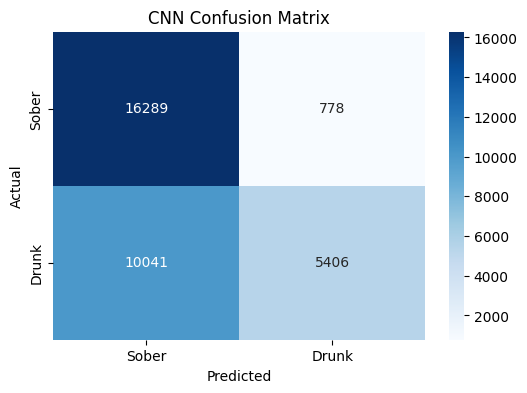

In [44]:
print("--- Final Deep Learning Performance (Test Set) ---")
print(classification_report(all_labels, all_preds, target_names=['Sober', 'Drunk']))

# Plot a Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sober', 'Drunk'], yticklabels=['Sober', 'Drunk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.show()

### MLP model

In [49]:
# 1. Split and Scale specifically for the MLP features
train_df_mlp = windowed_data[windowed_data['pid'].isin(train_pids)].copy()
val_df_mlp   = windowed_data[windowed_data['pid'].isin(val_pids)].copy()
test_df_mlp  = windowed_data[windowed_data['pid'].isin(test_pids)].copy()

# 2. Separate Features (Drop the non-numeric columns)
X_train_mlp = train_df_mlp.drop(columns=['label', 'pid'])
y_train_mlp = train_df_mlp['label']
X_val_mlp   = val_df_mlp.drop(columns=['label', 'pid'])
y_val_mlp   = val_df_mlp['label']
X_test_mlp  = test_df_mlp.drop(columns=['label', 'pid'])
y_test_mlp  = test_df_mlp['label']

# 3. Scaling (MLP is very sensitive to scale!)
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train_mlp)
X_val_scaled   = scaler_mlp.transform(X_val_mlp)
X_test_scaled  = scaler_mlp.transform(X_test_mlp)

# 4. Create Loaders
train_loader_mlp = DataLoader(SensorDataset(pd.DataFrame(X_train_scaled), y_train_mlp), batch_size=64, shuffle=True)
val_loader_mlp   = DataLoader(SensorDataset(pd.DataFrame(X_val_scaled), y_val_mlp), batch_size=64, shuffle=False)
test_loader_mlp  = DataLoader(SensorDataset(pd.DataFrame(X_test_scaled), y_test_mlp), batch_size=64, shuffle=False)

In [50]:
class AlcoholDetectionMLP(nn.Module):
    def __init__(self, input_dim):
        super(AlcoholDetectionMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.network(x)

# Initialize
input_dim = X_train_mlp.shape[1] # This should be 11
mlp_model = AlcoholDetectionMLP(input_dim).to(device)

In [63]:
torch.manual_seed(42)

# Initialize Optimizer and Loss
optimizer = optim.Adam(mlp_model.parameters(), lr=0.0001) # Standard LR for MLP
criterion = nn.BCELoss()

num_epochs = 150
best_mlp_val_loss = float('inf')

for epoch in range(num_epochs):
    mlp_model.train()
    train_loss = 0
    for inputs, labels in train_loader_mlp:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = mlp_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    mlp_model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader_mlp:
            inputs, labels = inputs.to(device), labels.to(device)
            val_loss += criterion(mlp_model(inputs), labels).item()
    
    avg_train = train_loss / len(train_loader_mlp)
    avg_val = val_loss / len(val_loader_mlp)
    
    if avg_val < best_mlp_val_loss:
        best_mlp_val_loss = avg_val
        torch.save(mlp_model.state_dict(), 'best_mlp_model.pth')
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss {avg_train:.4f} | Val Loss {avg_val:.4f}")

Epoch 10: Train Loss 0.4315 | Val Loss 0.3322
Epoch 20: Train Loss 0.4313 | Val Loss 0.3318
Epoch 30: Train Loss 0.4308 | Val Loss 0.3291
Epoch 40: Train Loss 0.4309 | Val Loss 0.3290
Epoch 50: Train Loss 0.4303 | Val Loss 0.3341
Epoch 60: Train Loss 0.4305 | Val Loss 0.3322
Epoch 70: Train Loss 0.4302 | Val Loss 0.3313
Epoch 80: Train Loss 0.4303 | Val Loss 0.3304
Epoch 90: Train Loss 0.4302 | Val Loss 0.3315
Epoch 100: Train Loss 0.4300 | Val Loss 0.3314
Epoch 110: Train Loss 0.4302 | Val Loss 0.3315
Epoch 120: Train Loss 0.4300 | Val Loss 0.3314
Epoch 130: Train Loss 0.4299 | Val Loss 0.3323
Epoch 140: Train Loss 0.4297 | Val Loss 0.3315
Epoch 150: Train Loss 0.4299 | Val Loss 0.3320


In [64]:
mlp_model.load_state_dict(torch.load('best_mlp_model.pth'))
mlp_model.eval()

all_mlp_preds = []
all_mlp_labels = []

with torch.no_grad():
    for inputs, labels in test_loader_mlp:
        inputs = inputs.to(device)
        outputs = mlp_model(inputs)
        preds = (outputs > 0.5).float()
        all_mlp_preds.extend(preds.cpu().numpy())
        all_mlp_labels.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report
print("--- MLP Performance (Test Set) ---")
print(classification_report(all_mlp_labels, all_mlp_preds, target_names=['Sober', 'Drunk']))

--- MLP Performance (Test Set) ---
              precision    recall  f1-score   support

       Sober       0.62      0.83      0.71      4263
       Drunk       0.71      0.44      0.54      3863

    accuracy                           0.65      8126
   macro avg       0.66      0.64      0.63      8126
weighted avg       0.66      0.65      0.63      8126



### Model Performance Comparison

| Model | Test F1-Score (Drunk) | Test Accuracy | Strengths |
| :--- | :---: | :---: | :--- |
| **Random Forest** | 0.61 | 65% | Best at identifying the "Drunk" class specifically; handles engineered features like "Sway" well. |
| **1D-CNN** | 0.50 | 67% | Overall Winner. Learned complex temporal patterns from raw signals that manual features missed. |
| **XG Boost** | 0.57 | 61% | Strong baseline for tabular data; handles non-linear relationships in features well. |
| **MLP** | 0.54 | 65% | Lightweight neural network; useful for validating if deep learning benefits from manual features. |